In [40]:
import numpy as np 
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import re
import string
import warnings
warnings.filterwarnings("ignore")

In [3]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/narendrafuloria/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
dataset = pd.read_csv("twitter_training.csv", header=None)

dataset.sample(10)

,0,1,2,3
50067,6194,FIFA,Negative,When pro clubs gave up the kits
37625,5251,Hearthstone,Neutral,been a good week 2 weekends of ECAC tournament...
34012,6641,Fortnite,Irrelevant,2012 The Best Way Forward to Protect the Galax...
23802,4479,Google,Neutral,When my family asks me about oscars major I ex...
12325,8518,NBA2K,Negative,@ NBA2K @ Ronnie2K HOW YES COME???????? How do...
59439,3388,Facebook,Negative,"Tech issues delayed Big Tech hearing as Apple,..."
11252,13135,Xbox(Xseries),Irrelevant,In the announcement of the launch of the Halo ...
57881,11525,TomClancysRainbowSix,Negative,la universe e gli account smurf. Fate is @ubis...
60612,3585,Facebook,Irrelevant,The struggles . @ajplascencia083 @Gonzalez_02_
58588,3244,Facebook,Irrelevant,Just blew around 3 + hours arguing with abuse ...


In [5]:
dataset.rename(columns = {1: "Product", 2: "Sentiment", 3: "Text"}, inplace = True)


dataset.sample(10)

,0,Product,Sentiment,Text
45250,11769,Verizon,Negative,I hate you yellow guys @Verizon never walk again
26968,1034,AssassinsCreed,Irrelevant,He watched some the assassins creed movie at t...
70252,10836,TomClancysGhostRecon,Neutral,Just overheard information in Ghost Recon : Br...
35212,8048,Microsoft,Negative,"A Damn, the bad lies keep here pilling her up!..."
42430,10079,PlayerUnknownsBattlegrounds(PUBG),Negative,Miss U S Pubg....
13816,8770,NBA2K,Positive,Best PG in the game Awards [UNK]..
39569,5591,Hearthstone,Neutral,Dragon mascot logo inspired from Hearthstone c...
18073,9898,PlayStation5(PS5),Positive,"I wish I would buy an MF, a PS5 baby that you ..."
52770,10666,RedDeadRedemption(RDR),Positive,This is the greatest thing ever
69530,3913,Cyberpunk2077,Positive,I'm so excited for cyberpunk 2077 to come out ...


In [6]:
dataset.drop(columns= 0, inplace = True)


In [7]:
dataset.head()

,Product,Sentiment,Text
0,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,Borderlands,Positive,I am coming to the borders and I will kill you...
2,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,Borderlands,Positive,im coming on borderlands and i will murder you...
4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [8]:
dataset["Sentiment"].value_counts()

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [9]:
encoder = LabelEncoder()

dataset["Sentiment"] = encoder.fit_transform(dataset["Sentiment"])

dataset.head()


,Product,Sentiment,Text
0,Borderlands,3,im getting on borderlands and i will murder yo...
1,Borderlands,3,I am coming to the borders and I will kill you...
2,Borderlands,3,im getting on borderlands and i will kill you ...
3,Borderlands,3,im coming on borderlands and i will murder you...
4,Borderlands,3,im getting on borderlands 2 and i will murder ...


In [10]:
labels = encoder.inverse_transform(dataset["Sentiment"].value_counts().index)
encoder.classes_

array(['Irrelevant', 'Negative', 'Neutral', 'Positive'], dtype=object)

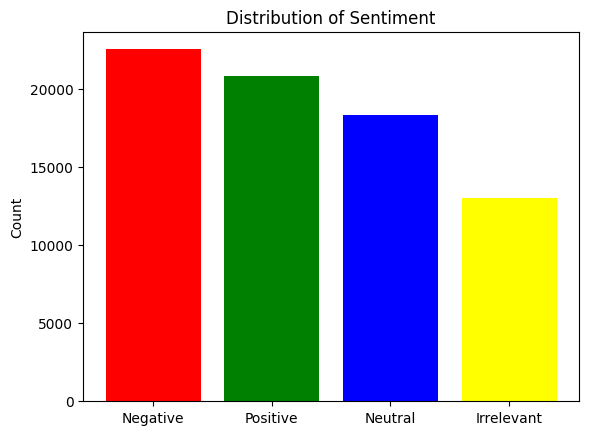

In [11]:
plt.bar(labels, dataset["Sentiment"].value_counts().values, color = ["red", "green", "blue" , "yellow"])
plt.ylabel("Count")
plt.title("Distribution of Sentiment")
plt.show()

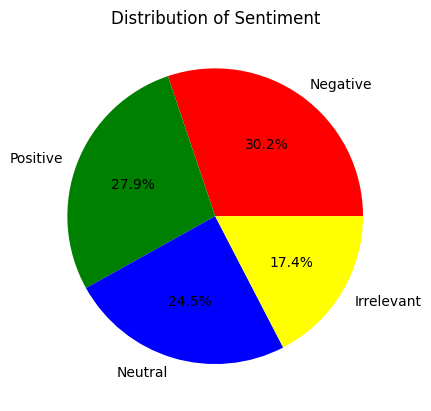

In [12]:
plt.pie(dataset["Sentiment"].value_counts().values, labels = labels, colors = ["red", "green", "blue" , "yellow"], autopct = "%1.1f%%")
plt.title("Distribution of Sentiment")
plt.show()

## EDA

In [13]:
dataset["num_characters"] = dataset["Text"].astype(str).apply(len)

In [14]:
dataset 

,Product,Sentiment,Text,num_characters
0,Borderlands,3,im getting on borderlands and i will murder yo...,53
1,Borderlands,3,I am coming to the borders and I will kill you...,51
2,Borderlands,3,im getting on borderlands and i will kill you ...,50
3,Borderlands,3,im coming on borderlands and i will murder you...,51
4,Borderlands,3,im getting on borderlands 2 and i will murder ...,57
...,...,...,...,...
74677,Nvidia,3,Just realized that the Windows partition of my...,128
74678,Nvidia,3,Just realized that my Mac window partition is ...,117
74679,Nvidia,3,Just realized the windows partition of my Mac ...,125
74680,Nvidia,3,Just realized between the windows partition of...,159


In [15]:
# num of words
dataset["num_words"] = dataset["Text"].astype(str).apply(lambda x: len(nltk.word_tokenize(x)))

In [16]:
dataset

,Product,Sentiment,Text,num_characters,num_words
0,Borderlands,3,im getting on borderlands and i will murder yo...,53,11
1,Borderlands,3,I am coming to the borders and I will kill you...,51,13
2,Borderlands,3,im getting on borderlands and i will kill you ...,50,11
3,Borderlands,3,im coming on borderlands and i will murder you...,51,11
4,Borderlands,3,im getting on borderlands 2 and i will murder ...,57,13
...,...,...,...,...,...
74677,Nvidia,3,Just realized that the Windows partition of my...,128,26
74678,Nvidia,3,Just realized that my Mac window partition is ...,117,24
74679,Nvidia,3,Just realized the windows partition of my Mac ...,125,27
74680,Nvidia,3,Just realized between the windows partition of...,159,32


In [17]:
# num of sentences
dataset["num_sentences"] = dataset["Text"].astype(str).apply(lambda x: len(nltk.sent_tokenize(x)))

In [18]:
dataset 

,Product,Sentiment,Text,num_characters,num_words,num_sentences
0,Borderlands,3,im getting on borderlands and i will murder yo...,53,11,1
1,Borderlands,3,I am coming to the borders and I will kill you...,51,13,1
2,Borderlands,3,im getting on borderlands and i will kill you ...,50,11,1
3,Borderlands,3,im coming on borderlands and i will murder you...,51,11,1
4,Borderlands,3,im getting on borderlands 2 and i will murder ...,57,13,1
...,...,...,...,...,...,...
74677,Nvidia,3,Just realized that the Windows partition of my...,128,26,1
74678,Nvidia,3,Just realized that my Mac window partition is ...,117,24,1
74679,Nvidia,3,Just realized the windows partition of my Mac ...,125,27,1
74680,Nvidia,3,Just realized between the windows partition of...,159,32,1


In [19]:
dataset[["num_characters", "num_words", "num_sentences"]].describe()    

,num_characters,num_words,num_sentences
count,74682.000000,74682.000000,74682.000000
mean,107.811963,22.392518,1.936692
std,79.798839,17.203393,1.630151
min,1.000000,0.000000,0.000000
25%,45.000000,9.000000,1.000000
50%,90.000000,18.000000,1.000000
75%,152.000000,31.000000,2.000000
max,957.000000,198.000000,33.000000


In [20]:
# details of the text with Irrelevant sentiment
dataset[dataset["Sentiment"] == 0][["num_characters", "num_words", "num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,12990.000000,12990.000000,12990.000000
mean,109.973980,22.901540,2.015319
std,79.378055,17.196458,1.725303
min,1.000000,0.000000,0.000000
25%,49.000000,10.000000,1.000000
50%,92.000000,18.000000,1.000000
75%,154.000000,32.000000,2.000000
max,692.000000,198.000000,25.000000


In [21]:
#details of the text with negative sentiment
dataset[dataset["Sentiment"] == 1][["num_characters", "num_words", "num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,22542.000000,22542.000000,22542.000000
mean,110.401828,23.100745,1.809422
std,82.095795,17.439634,1.359893
min,1.000000,0.000000,0.000000
25%,45.000000,9.000000,1.000000
50%,90.000000,19.000000,1.000000
75%,160.000000,33.000000,2.000000
max,727.000000,198.000000,22.000000


In [22]:
#details of the text with neutral sentiment
dataset[dataset["Sentiment"] == 2][["num_characters", "num_words", "num_sentences"]].describe()


,num_characters,num_words,num_sentences
count,18318.000000,18318.000000,18318.000000
mean,117.506660,23.762965,2.095152
std,77.955804,17.127248,1.883475
min,1.000000,0.000000,0.000000
25%,60.000000,12.000000,1.000000
50%,104.000000,20.000000,1.000000
75%,160.000000,33.000000,3.000000
max,957.000000,198.000000,31.000000


In [23]:
# details of the text with positive sentiment
dataset[dataset["Sentiment"] == 3][["num_characters", "num_words", "num_sentences"]].describe()


,num_characters,num_words,num_sentences
count,20832.000000,20832.000000,20832.000000
mean,95.136617,20.103687,1.886041
std,77.526184,16.792736,1.582534
min,1.000000,0.000000,0.000000
25%,35.000000,8.000000,1.000000
50%,74.000000,15.000000,1.000000
75%,133.000000,28.000000,2.000000
max,692.000000,198.000000,33.000000


<Axes: xlabel='num_characters', ylabel='Count'>

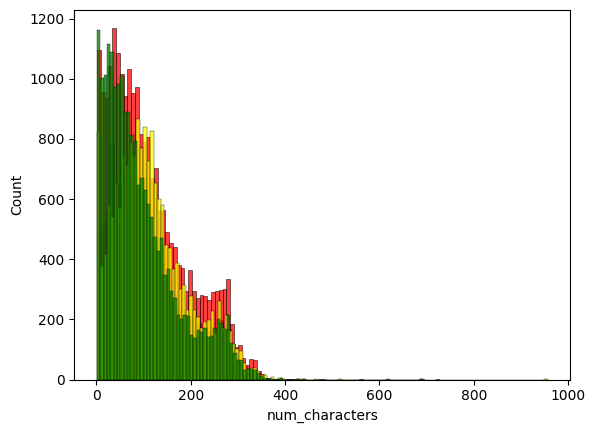

In [24]:
sns.histplot(dataset[dataset["Sentiment"] == 0]["num_characters"])
sns.histplot(dataset[dataset["Sentiment"] == 1]["num_characters"], color= "red")
sns.histplot(dataset[dataset["Sentiment"] == 2]["num_characters"], color = "yellow")
sns.histplot(dataset[dataset["Sentiment"] == 3]["num_characters"], color = "green")



<Axes: xlabel='num_words', ylabel='Count'>

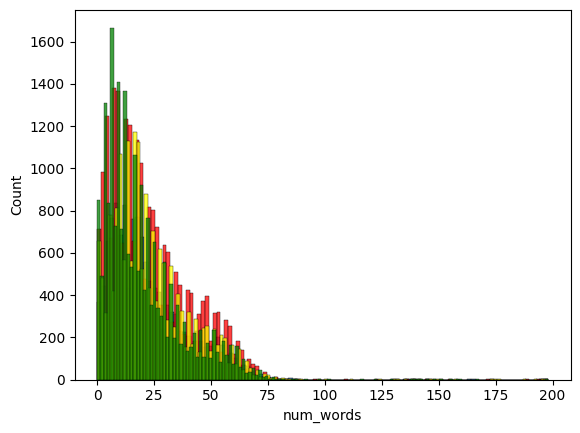

In [25]:
sns.histplot(dataset[dataset["Sentiment"] == 0]["num_words"])
sns.histplot(dataset[dataset["Sentiment"] == 1]["num_words"], color= "red")
sns.histplot(dataset[dataset["Sentiment"] == 2]["num_words"], color = "yellow")
sns.histplot(dataset[dataset["Sentiment"] == 3]["num_words"], color = "green")

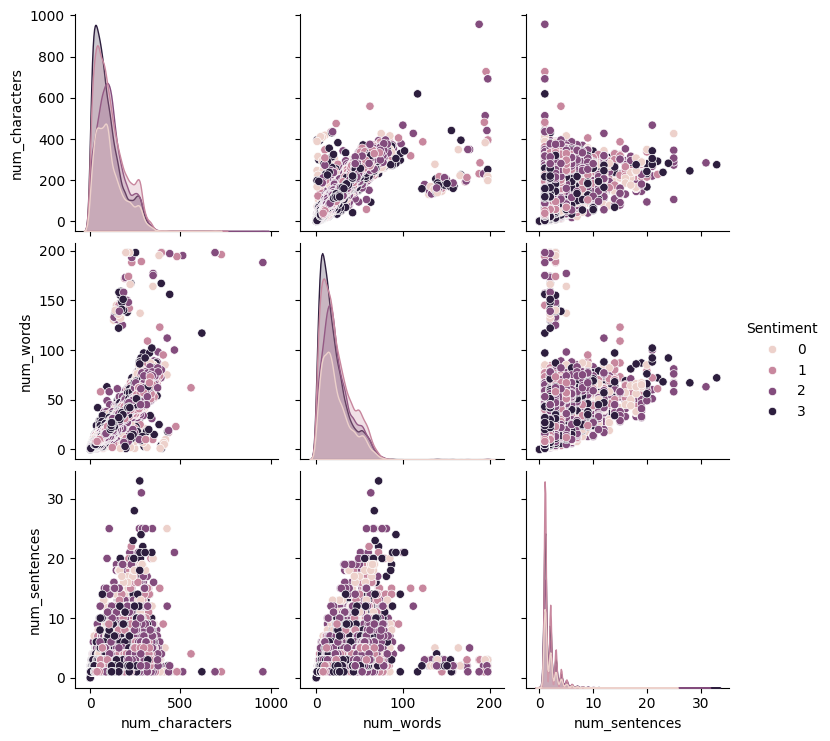

In [26]:
sns.pairplot(dataset, hue = "Sentiment")

<Axes: >

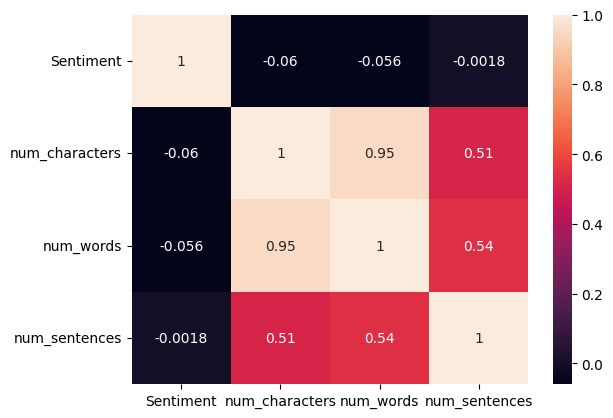

In [27]:
sns.heatmap(dataset.select_dtypes(include=['number']).corr(), annot= True)

# Data Preprocessing

lowercase

tokenisation

Removing special characters

Removing stop words and punctuation

Stemming

In [28]:
# defining a function to convert text to lowercase, tokenise the text, and remove stop words, punctuation and special characters from the text and stem the text
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import nltk
import re   

ps = PorterStemmer()

def transform_text(text):
    text = str(text).lower()
    
    # REMOVE URLs (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    text = nltk.word_tokenize(text)
    
    y = []
    
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words("english") and i not in ["@", "#"]:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [29]:
dataset["transformed_text"] = dataset["Text"].apply(transform_text)
dataset.head()

,Product,Sentiment,Text,num_characters,num_words,num_sentences,transformed_text
0,Borderlands,3,im getting on borderlands and i will murder yo...,53,11,1,im get borderland murder
1,Borderlands,3,I am coming to the borders and I will kill you...,51,13,1,come border kill
2,Borderlands,3,im getting on borderlands and i will kill you ...,50,11,1,im get borderland kill
3,Borderlands,3,im coming on borderlands and i will murder you...,51,11,1,im come borderland murder
4,Borderlands,3,im getting on borderlands 2 and i will murder ...,57,13,1,im get borderland 2 murder


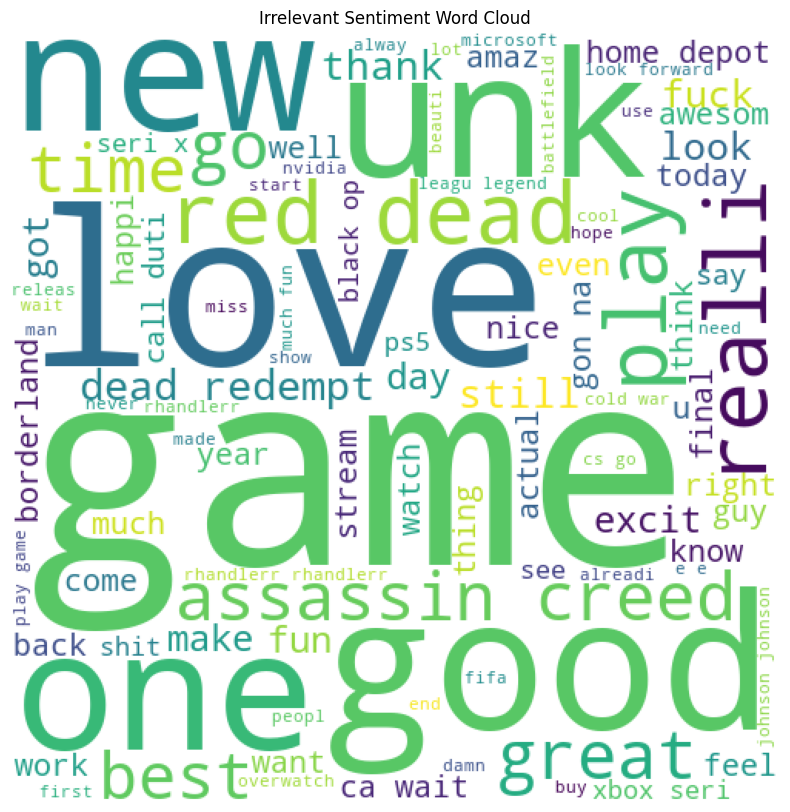

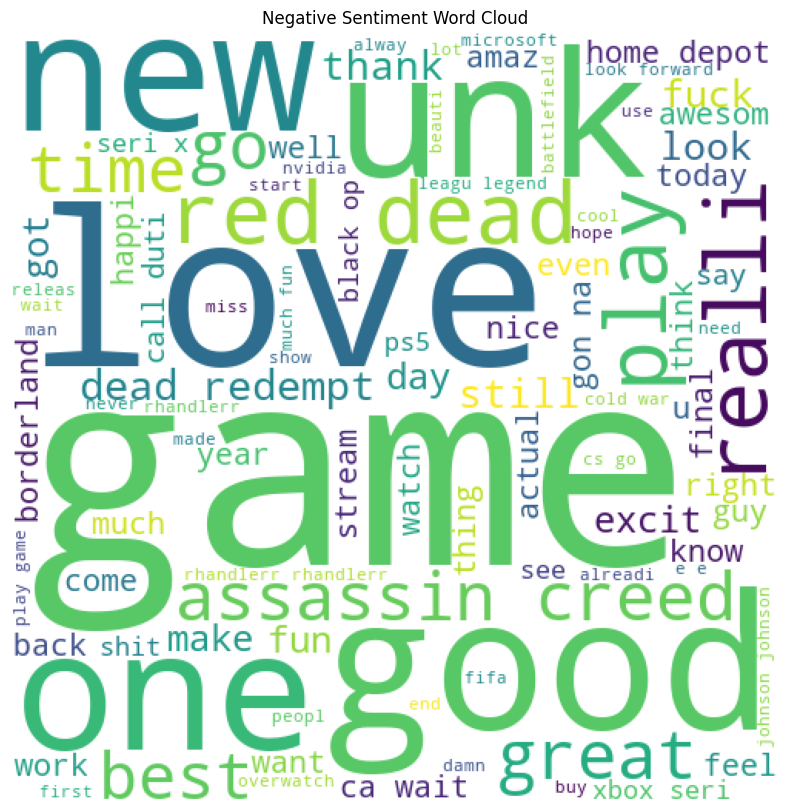

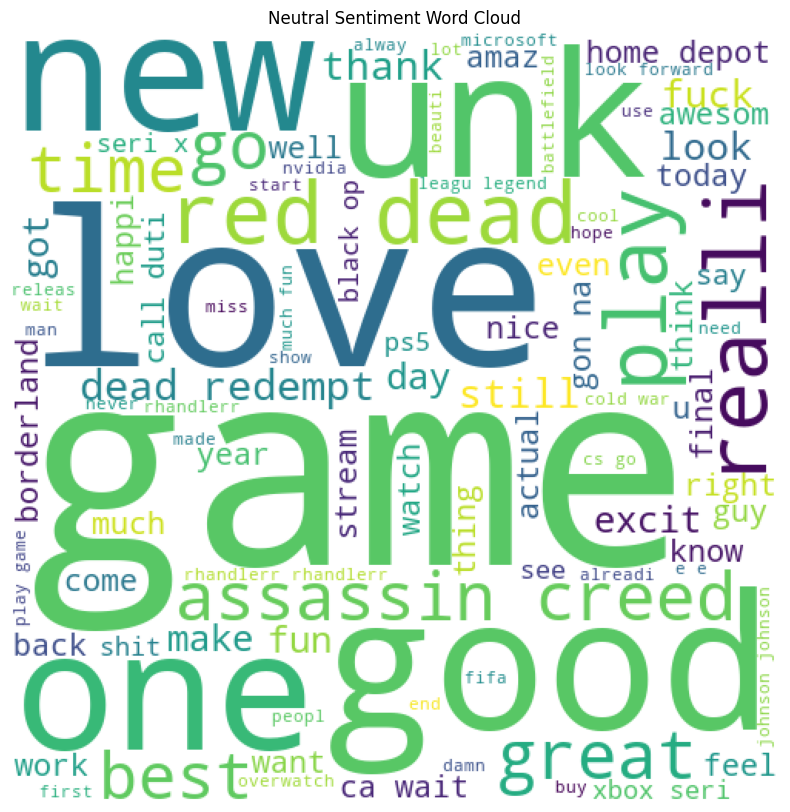

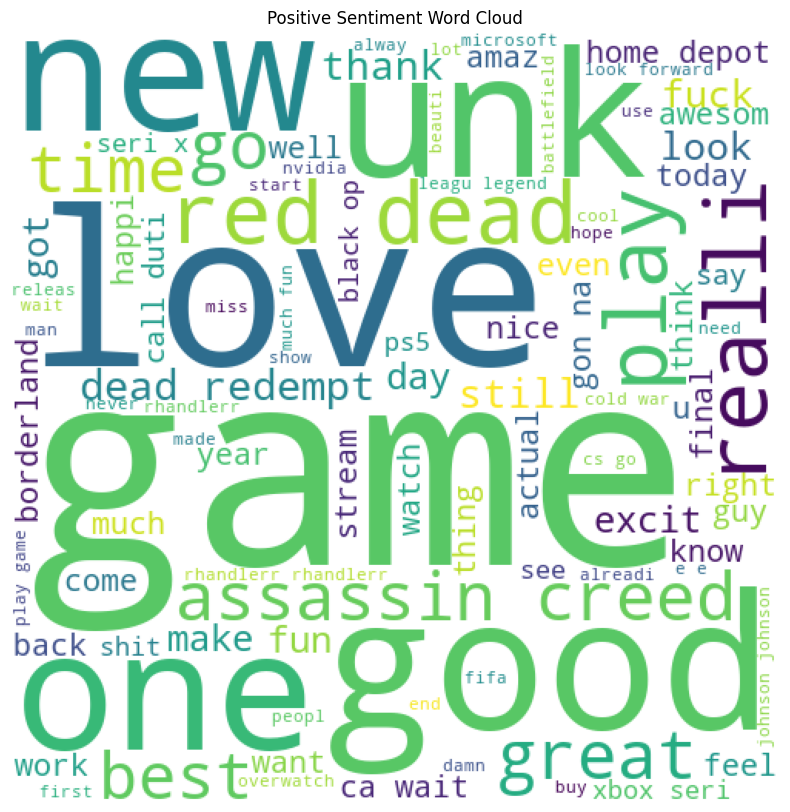

In [31]:
# generating word cloud for all kind of sentiments
from wordcloud import WordCloud
wc = WordCloud(width = 500, height = 500, min_font_size = 10, background_color = "white")

Irrelevant_wc = wc.generate(dataset[dataset["Sentiment"] == 0]["transformed_text"].str.cat(sep = " "))
negative_wc = wc.generate(dataset[dataset["Sentiment"] == 1]["transformed_text"].str.cat(sep = " "))
neutral_wc = wc.generate(dataset[dataset["Sentiment"] == 2]["transformed_text"].str.cat(sep = " "))
positive_wc = wc.generate(dataset[dataset["Sentiment"] == 3]["transformed_text"].str.cat(sep = " "))
plt.figure(figsize = (10, 10))
plt.imshow(Irrelevant_wc)
plt.axis("off")
plt.title("Irrelevant Sentiment Word Cloud")
plt.show()
plt.figure(figsize = (10, 10))
plt.imshow(negative_wc)
plt.axis("off")
plt.title("Negative Sentiment Word Cloud")
plt.show()
plt.figure(figsize = (10, 10))
plt.imshow(neutral_wc)
plt.axis("off")
plt.title("Neutral Sentiment Word Cloud")
plt.show()
plt.figure(figsize = (10, 10))
plt.imshow(positive_wc)
plt.axis("off")
plt.title("Positive Sentiment Word Cloud")
plt.show()


In [32]:
irrelevant_corpus = []
irrelevant_sent = dataset[dataset["Sentiment"] == 0]["transformed_text"]
for i in irrelevant_sent:
    for j in i.split():
        irrelevant_corpus.append(j)
len(irrelevant_corpus)

136968

In [33]:
# negative corpus
negative_corpus = []
negative_sent = dataset[dataset["Sentiment"] == 1]["transformed_text"]
for i in negative_sent:
    for j in i.split():
        negative_corpus.append(j)
len(negative_corpus)

243542

In [34]:
# neutral corpus
neutral_corpus = []
neutral_sent = dataset[dataset["Sentiment"] == 2]["transformed_text"]
for i in neutral_sent:      
    for j in i.split():
        neutral_corpus.append(j)    
len(neutral_corpus)

204613

In [35]:
#positive corpus
positive_corpus = []
positive_sent = dataset[dataset["Sentiment"] == 3]["transformed_text"]
for i in positive_sent:
    for j in i.split():
        positive_corpus.append(j)
len(positive_corpus)

195719

In [36]:
from collections import Counter
Counter(irrelevant_corpus).most_common(500)


[('game', 1211),
 ('player', 1128),
 ('like', 1093),
 ('see', 1063),
 ('ban', 948),
 ('play', 815),
 ('love', 792),
 ('go', 778),
 ('peopl', 777),
 ('get', 768),
 ('fuck', 726),
 ('one', 710),
 ('good', 663),
 ('unk', 620),
 ('4', 614),
 ('best', 612),
 ('thank', 595),
 ('realli', 546),
 ('battlefield', 540),
 ('time', 520),
 ('2', 512),
 ('look', 501),
 ('shit', 493),
 ('got', 487),
 ('even', 472),
 ('detail', 454),
 ('great', 452),
 ('make', 452),
 ('pubg', 451),
 ('would', 446),
 ('team', 446),
 ('gta', 445),
 ('overwatch', 436),
 ('call', 434),
 ('guy', 416),
 ('stream', 407),
 ('live', 387),
 ('occur', 387),
 ('say', 381),
 ('know', 379),
 ('new', 377),
 ('facebook', 377),
 ('fifa', 372),
 ('want', 371),
 ('fortnit', 370),
 ('use', 355),
 ('come', 353),
 ('work', 353),
 ('watch', 350),
 ('video', 349),
 ('xbox', 349),
 ('today', 335),
 ('googl', 330),
 ('pleas', 329),
 ('us', 324),
 ('first', 320),
 ('day', 306),
 ('still', 305),
 ('world', 305),
 ('year', 304),
 ('think', 298),
 

In [37]:
Counter(negative_corpus).most_common(500)

[('game', 4601),
 ('fuck', 2476),
 ('get', 2374),
 ('play', 2085),
 ('like', 1695),
 ('shit', 1543),
 ('fix', 1454),
 ('go', 1290),
 ('make', 1183),
 ('time', 1137),
 ('pleas', 1126),
 ('eamaddennfl', 1090),
 ('still', 1054),
 ('one', 1033),
 ('even', 996),
 ('peopl', 984),
 ('realli', 983),
 ('verizon', 936),
 ('got', 924),
 ('rainbow6gam', 900),
 ('fifa', 883),
 ('unk', 880),
 ('year', 868),
 ('2', 850),
 ('work', 824),
 ('tri', 813),
 ('nba2k', 808),
 ('johnson', 796),
 ('new', 786),
 ('server', 785),
 ('ca', 769),
 ('call', 745),
 ('look', 699),
 ('bad', 690),
 ('say', 689),
 ('facebook', 688),
 ('guy', 687),
 ('want', 680),
 ('rhandlerr', 680),
 ('know', 679),
 ('day', 671),
 ('updat', 670),
 ('back', 667),
 ('microsoft', 640),
 ('help', 639),
 ('player', 629),
 ('everi', 618),
 ('home', 616),
 ('use', 614),
 ('need', 613),
 ('3', 610),
 ('good', 609),
 ('googl', 593),
 ('problem', 587),
 ('never', 587),
 ('ban', 572),
 ('damn', 562),
 ('see', 557),
 ('think', 553),
 ('xbox', 543)

In [38]:
Counter(neutral_corpus).most_common(500)

[('game', 1832),
 ('johnson', 1819),
 ('play', 1518),
 ('2', 1241),
 ('get', 1200),
 ('amazon', 1152),
 ('like', 989),
 ('one', 881),
 ('googl', 852),
 ('new', 850),
 ('facebook', 845),
 ('go', 844),
 ('unk', 828),
 ('time', 748),
 ('microsoft', 721),
 ('see', 702),
 ('3', 698),
 ('good', 695),
 ('dead', 690),
 ('thank', 677),
 ('red', 671),
 ('nvidia', 665),
 ('video', 651),
 ('peopl', 645),
 ('com', 642),
 ('love', 639),
 ('watch', 624),
 ('make', 621),
 ('us', 620),
 ('xbox', 609),
 ('day', 605),
 ('look', 590),
 ('5', 579),
 ('live', 569),
 ('best', 562),
 ('great', 562),
 ('win', 547),
 ('verizon', 526),
 ('2020', 506),
 ('world', 502),
 ('tri', 492),
 ('got', 483),
 ('1', 479),
 ('come', 473),
 ('redempt', 473),
 ('first', 468),
 ('use', 467),
 ('home', 461),
 ('stop', 459),
 ('legend', 459),
 ('x', 457),
 ('via', 453),
 ('even', 453),
 ('today', 451),
 ('want', 448),
 ('fuck', 447),
 ('realli', 446),
 ('rhandlerr', 446),
 ('check', 441),
 ('work', 441),
 ('news', 441),
 ('http',

In [39]:
Counter(positive_corpus).most_common(500)

[('game', 3275),
 ('play', 2549),
 ('love', 2112),
 ('good', 1627),
 ('like', 1465),
 ('thank', 1310),
 ('get', 1304),
 ('realli', 1281),
 ('new', 1200),
 ('look', 1195),
 ('go', 1153),
 ('time', 1147),
 ('2', 1122),
 ('best', 1113),
 ('one', 1101),
 ('great', 995),
 ('fun', 921),
 ('wait', 918),
 ('3', 855),
 ('see', 818),
 ('unk', 779),
 ('year', 757),
 ('borderland', 736),
 ('fuck', 728),
 ('red', 726),
 ('excit', 721),
 ('day', 712),
 ('dead', 705),
 ('still', 697),
 ('amaz', 691),
 ('much', 685),
 ('got', 675),
 ('make', 670),
 ('creed', 666),
 ('assassin', 661),
 ('back', 657),
 ('xbox', 618),
 ('work', 603),
 ('want', 603),
 ('rhandlerr', 596),
 ('come', 583),
 ('final', 572),
 ('redempt', 561),
 ('today', 556),
 ('happi', 554),
 ('stream', 553),
 ('nice', 538),
 ('would', 528),
 ('ca', 520),
 ('peopl', 517),
 ('feel', 514),
 ('know', 507),
 ('ever', 502),
 ('home', 495),
 ('ps5', 491),
 ('microsoft', 482),
 ('nvidia', 482),
 ('first', 478),
 ('wow', 475),
 ('think', 468),
 ('th

In [44]:
data_train, data_test = train_test_split(dataset, test_size = 0.2, random_state = 42, stratify= dataset["Sentiment"])

In [45]:
data_train.shape

(59745, 7)

In [46]:
data_test.shape

(14937, 7)

In [48]:

# Define parameters clearly
VOCAB_SIZE = 5000
MAX_LEN = 200
OOV_TOKEN = "<OOV>"

# Initialize tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)

# Fit ONLY on training data (correct 👍)
tokenizer.fit_on_texts(data_train["transformed_text"])

# Convert text → sequences
train_sequences = tokenizer.texts_to_sequences(data_train["transformed_text"])
test_sequences = tokenizer.texts_to_sequences(data_test["transformed_text"])

# Pad sequences (explicit settings)
X_train = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)



In [ ]:
y_train = data_train["Sentiment"].values
y_test = data_test["Sentiment"].values


array([2, 1, 3, ..., 2, 1, 2])

In [51]:
# Build the model
model = Sequential()
model.add(Embedding(VOCAB_SIZE, output_dim= 128, input_length=MAX_LEN))
model.add(LSTM(128, dropout= 0.2, recurrent_dropout= 0.2))
model.add(Dense(4, activation="softmax"))

2026-04-14 13:40:37.466620: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-14 13:40:37.466972: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-14 13:40:37.466980: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-14 13:40:37.467264: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-14 13:40:37.467301: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [52]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
# complile the mode
model.compile(loss = "sparse_categorical_crossentropy", optimizer = "adam", metrics = ["accuracy"])

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=2,             # stop if no improvement for 2 epochs
    restore_best_weights=True)

model.fit(X_train, y_train, epochs = 10, validation_split= 0.2, callbacks=[early_stop])

Epoch 1/10


2026-04-14 14:05:09.576882: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  12/1494 ━━━━━━━━━━━━━━━━━━━━ 17:41:03 43s/step - accuracy: 0.2654 - loss: 1.3879

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")